# Neural HJM Residual Model — Experimental

Companion to [`ycs_af_models.ipynb`](ycs_af_models.ipynb), which covers the two
closed-form arbitrage-free models (AFNS, DTAFNS). This notebook covers the
third and last model in the registry, `ResidualModel.NEURAL_HJM`, in its own
notebook for reasons that matter enough to read before any of its numbers:

* **Needs an optional dependency.** `torch` is behind the `neural` extra
  (`uv sync --extra neural`) so the core package stays torch-free.
* **Its residuals are a different statistical object.** Every other model in
  this project produces *cross-sectional* residuals — refit independently at
  each date from that date's own cross-section. The neural model's residuals
  are *filtered, in-sample* residuals from a model trained once on the whole
  series. `af_compare.FILTERED_RESIDUAL_MODELS` flags this, and comparing its
  RMSE to the others' like-for-like is misleading — smaller is partly just
  "the model has already seen this data."
* **It is an explicitly partial implementation.** Gao & Hyndman (2025,
  arXiv:2511.17892) publish no code or hyperparameters, so `ycn` implements a
  documented *subset*: a DNS forward-rate parameterisation, an LSTM latent
  state, a learned-gain correction, and the HJM no-arbitrage drift restriction
  as a soft training penalty. It omits the paper's Extended Kalman Filter,
  particle filter and convolutional-LSTM variants. None of its numbers can be
  checked against the paper's, because the paper publishes none to check
  against.

Uses the **same panel and date range** as `ycs_af_models.ipynb`, so its
Chapter C baseline (NS, AFNS) lines up with that notebook's Chapter C exactly.

In [1]:
import warnings

warnings.filterwarnings("ignore")

from datetime import date

import numpy as np
import polars as pl
from IPython.display import display
from plotnine import aes, geom_line, geom_point, ggplot, labs, theme_minimal

try:
    import torch  # noqa: F401
except ImportError as exc:
    raise ImportError(
        "This notebook needs the optional neural extra: "
        "run `uv sync --extra neural`, then restart the kernel."
    ) from exc

from ycn.analysis.config import PipelineConfig
from ycn.analysis.yield_curve import detect_panel, load_long_panel, NetworkKind
from ycn.analysis.af_models import ModelSpec, ResidualModel, NeuralSpec, fit_panel
from ycn.analysis.af_neural import adjustment_shapes
from ycn.analysis.af_compare import compare_residual_models, summarize
from ycn.analysis.af_references import references_for, format_bibliography
from ycn.analysis import af_compare_viz as viz
from ycn.analysis.network import pivot_to_wide
from ycn.analysis.residual_networks import (
    _canonical_maturities,
    _canonical_maturity_values,
    _dense_rows,
)

print(f"torch {torch.__version__}")

torch 2.13.0+cpu


## Chapter A: Load the same panel as `ycs_af_models.ipynb`

In [2]:
DB = r"D:\data\duckdb\ycs_data.duckdb"
TABLE = "zero_rates"

panel = detect_panel(DB, TABLE, "date")
cfg = PipelineConfig(
    db_path=DB,
    table=TABLE,
    date_column="date",
    name_column=panel.term_column,
    value_column=panel.rate_column,
    date_start=date(2021, 1, 1),
    date_end=date(2024, 1, 1),
    issuer_column=panel.issuer_column,
    term_columns=list(panel.term_columns),
)
long = load_long_panel(cfg, panel)
print(
    f"Loaded {long.height:,} rows, "
    f"{long[panel.issuer_column].n_unique()} issuers, "
    f"{long['date'].n_unique()} dates"
)

Loaded 396,609 rows, 20 issuers, 841 dates


## Chapter B: `NeuralSpec` — the model's knobs

| Field | Default | Role |
|---|---|---|
| `hidden_size` | 32 | LSTM hidden state width |
| `n_layers` | 1 | LSTM depth |
| `epochs` | 600 | Training iterations (full-batch Adam) |
| `learning_rate` | 1e-2 | Adam step size |
| `drift_weight` | 0.1 | Weight on the HJM no-arbitrage penalty |
| `smooth_weight` | 1e-3 | Weight on a state-increment (smoothness) penalty |

The `drift_weight` term is the point of the whole model: Heath, Jarrow &
Morton (1992) show that absence of arbitrage restricts a forward-rate model's
drift to be determined by its own volatility. `drift_weight` controls how hard
that restriction is enforced during training relative to pure reconstruction
accuracy — `0.0` recovers an unconstrained curve-fitting LSTM with no
arbitrage-free property at all.

The network's learned gain multiplies fixed AFNS-style shape functions of
maturity (`adjustment_shapes`, pure numpy, no torch needed) rather than
producing an unconstrained correction — this is what keeps the correction's
*functional form* tied to the arbitrage-free literature even though its
*magnitude* is learned and time-varying.

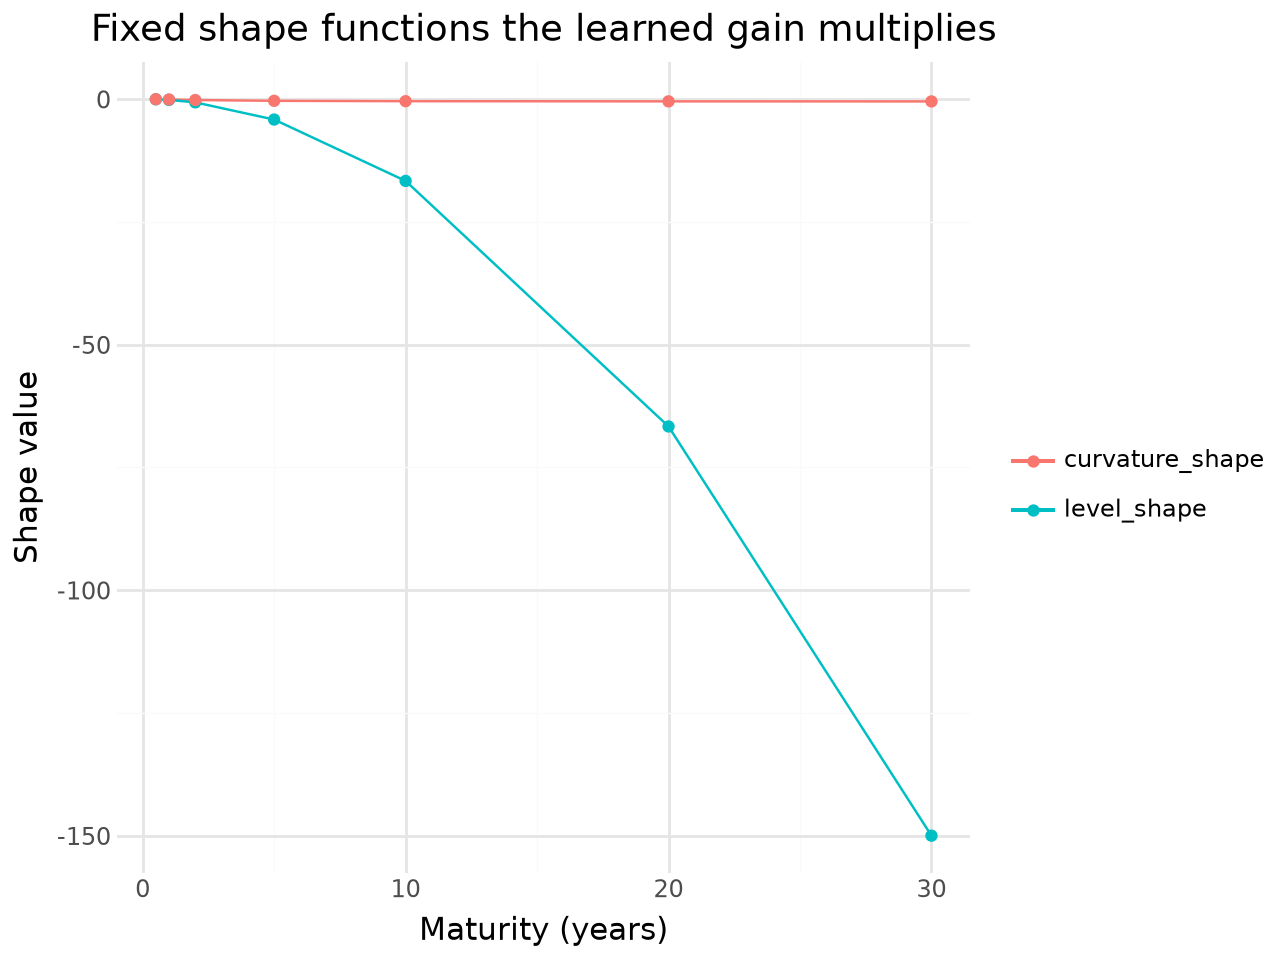

In [3]:
maturities = np.array([0.5, 1, 2, 5, 10, 20, 30])
shapes = adjustment_shapes(maturities, decay=1.0)

shape_df = pl.DataFrame(
    {
        "maturity": maturities,
        "level_shape": shapes[:, 0],
        "curvature_shape": shapes[:, 1],
    }
).unpivot(index="maturity", variable_name="component", value_name="value")

(
    ggplot(shape_df.to_pandas(), aes("maturity", "value", colour="component"))
    + geom_line()
    + geom_point()
    + labs(
        title="Fixed shape functions the learned gain multiplies",
        x="Maturity (years)",
        y="Shape value",
        colour="",
    )
    + theme_minimal()
)

## Chapter C: Fit NS, AFNS and Neural HJM across all 20 issuers

**This cell takes roughly 2 minutes** (benchmarked: about 6 seconds per issuer
for 600 epochs, times 20 issuers, plus the near-instant NS/AFNS fits).
`seed=0` on the `ModelSpec` makes the LSTM's initialisation and training
reproducible.

In [4]:
specs = [
    ModelSpec(ResidualModel.NS),
    ModelSpec(ResidualModel.AFNS),
    ModelSpec(ResidualModel.NEURAL_HJM, seed=0, neural=NeuralSpec(epochs=600)),
]

comparison = compare_residual_models(
    long,
    panel,
    NetworkKind.ISSUER_BY_TERM,
    "date",
    specs=specs,
    threshold=0.3,
)

display(
    summarize(comparison).select(
        ["model", "rmse_all", "rmse_long", "rmse_short", "filtered_residuals"]
    )
)

if comparison.residuals.get_column("filtered_residuals").any():
    print(
        "\nNOTE: neural_hjm reports FILTERED in-sample residuals -- not the same "
        "statistical object as NS/AFNS's cross-sectional residuals. Its RMSE is "
        "not directly comparable to theirs; see the notebook header."
    )

model,rmse_all,rmse_long,rmse_short,filtered_residuals
str,f64,f64,f64,bool
"""ns""",0.11247,0.112198,0.153588,false
"""neural_hjm/per_issuer""",0.130695,0.131377,0.172601,true
"""afns/per_issuer""",0.305818,0.367182,0.326399,false



NOTE: neural_hjm reports FILTERED in-sample residuals -- not the same statistical object as NS/AFNS's cross-sectional residuals. Its RMSE is not directly comparable to theirs; see the notebook header.


## Chapter D: Residual RMSE — read this one with the caveat in mind

The neural model's RMSE sits in the same neighbourhood as plain NS's here,
which sounds like "does about as well" — but keep the filtered/cross-sectional
distinction in mind. NS re-derives its factors independently at every date
from that date's own cross-section and has never seen any other date; the
neural model has been trained once on the whole series and is being evaluated
on data it optimised against. A close RMSE here is a much weaker claim than it
would be for two cross-sectional models.

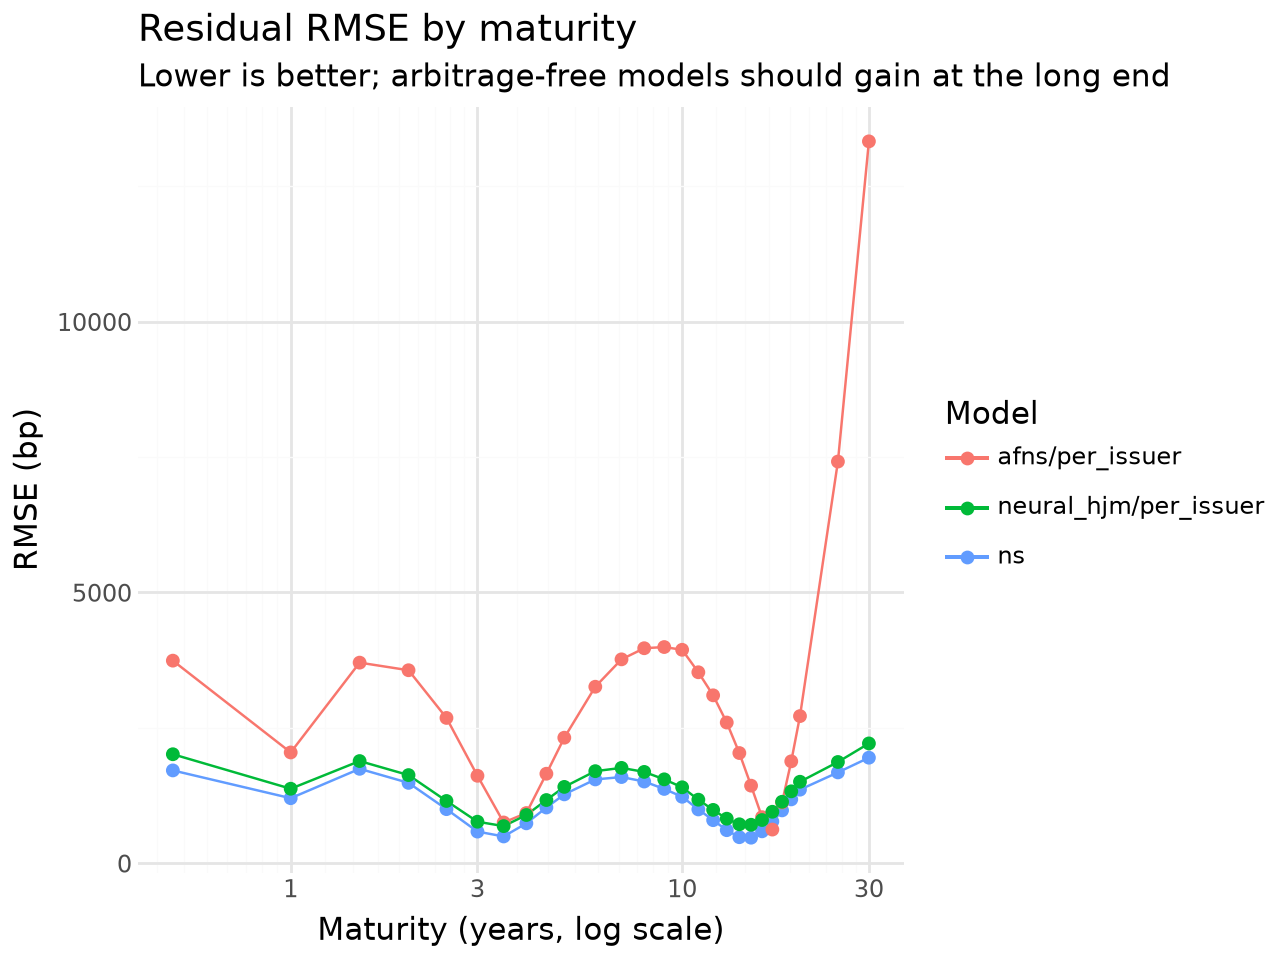

In [5]:
viz.plot_rmse_by_maturity(comparison)

## Chapter E: Does the neural model's residual network actually differ?

`ycs_af_models.ipynb` Chapter H proves that AFNS and DTAFNS **cannot** change
the residual network relative to plain NS, because their yield adjustment is a
time-invariant offset and correlation is invariant under adding a constant.

The neural model's correction has no such guarantee. It is a **learned,
per-date** quantity from the LSTM's hidden state, not a single offset fitted
once over the whole sample — so the invariance argument simply does not apply
to it. Whether that actually shows up in the networks is an empirical
question, not a proof, so here is the same agreement chart from Chapter H run
against this model.

model_a,model_b,min,mean,max,layers_that_differ,n_layers
str,str,f64,f64,f64,u32,u32
"""afns/per_issuer""","""neural_hjm/per_issuer""",0.301887,0.58058,0.813559,27,27
"""ns""","""afns/per_issuer""",1.0,1.0,1.0,0,27
"""ns""","""neural_hjm/per_issuer""",0.301887,0.58058,0.813559,27,27


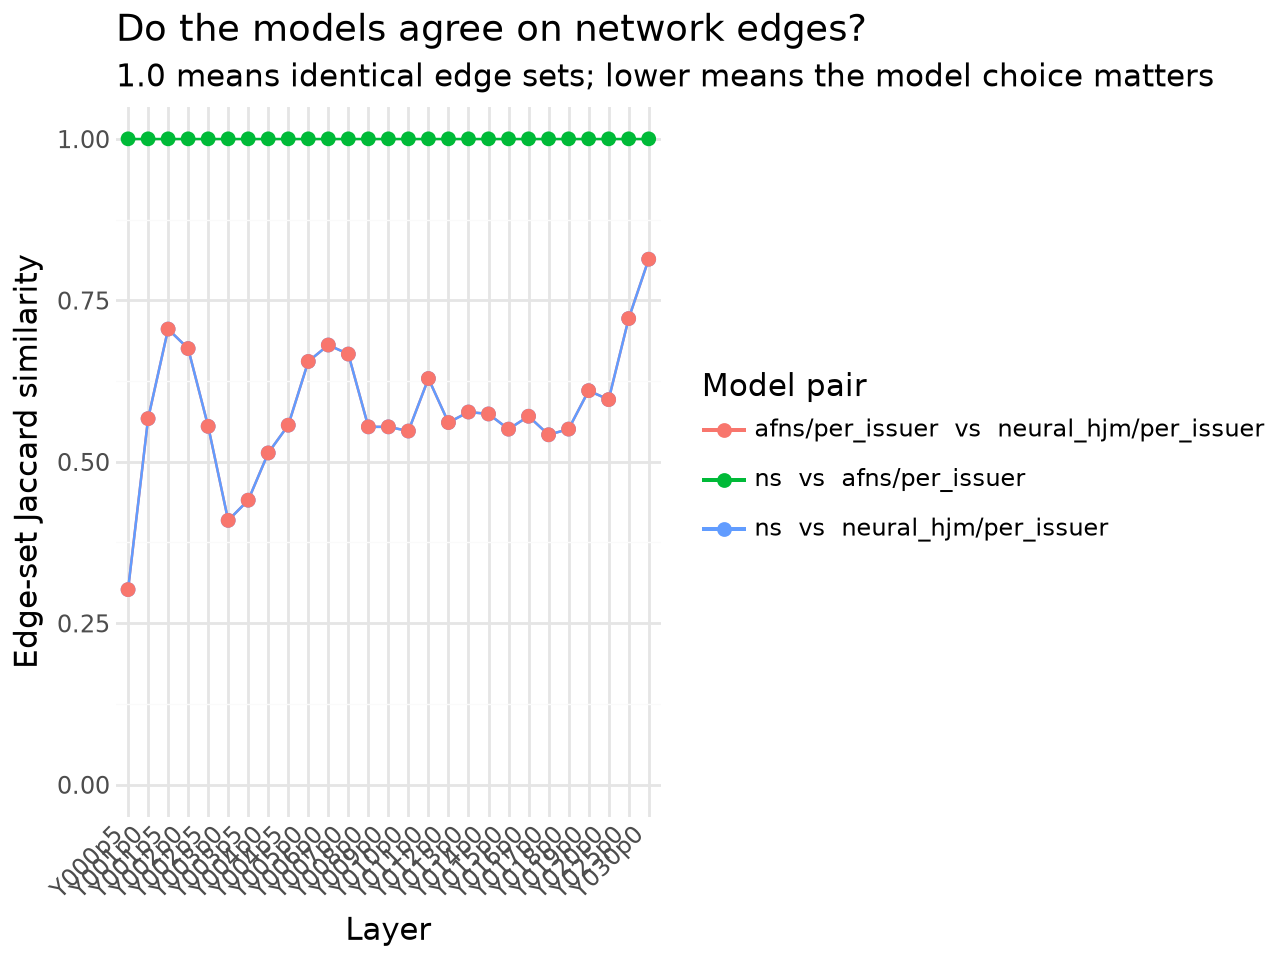

In [6]:
per_layer = comparison.agreement.filter(pl.col("label") != "__all__")
display(
    per_layer.group_by(["model_a", "model_b"]).agg(
        pl.col("edge_jaccard").min().alias("min"),
        pl.col("edge_jaccard").mean().alias("mean"),
        pl.col("edge_jaccard").max().alias("max"),
        (pl.col("edge_jaccard") < 0.999).sum().alias("layers_that_differ"),
        pl.len().alias("n_layers"),
    )
)
viz.plot_edge_agreement(comparison)

Unlike Chapter H's flat line at 1.0, edge-set agreement between NS/AFNS and
the neural model varies substantially by maturity layer and is well below 1.0
at several of them. The curve-model choice **does** change which issuers the
network says move together once the correction is allowed to vary over time
— exactly the case the invariance proof in `ycs_af_models.ipynb` excludes, and
the reason this model is interesting despite its residuals not being directly
comparable in level.

## Chapter F: Hyperparameter sensitivity — the arbitrage-penalty weight

A single-issuer diagnostic rather than a network comparison, so this calls
`fit_panel` directly instead of the multi-model harness (whose `ModelSpec.name`
does not distinguish specs that only differ by a `NeuralSpec` field).
`drift_weight=0.0` disables the no-arbitrage penalty entirely, reducing the
model to an unconstrained curve-fitting LSTM.

drift_weight,rmse,max_abs_adjustment
f64,f64,f64
0.0,0.08888,0.03771
0.05,0.108174,0.156722
0.1,0.110665,0.167863
0.25,0.112867,0.173543
0.5,0.129956,0.175347
1.0,0.123852,0.205335


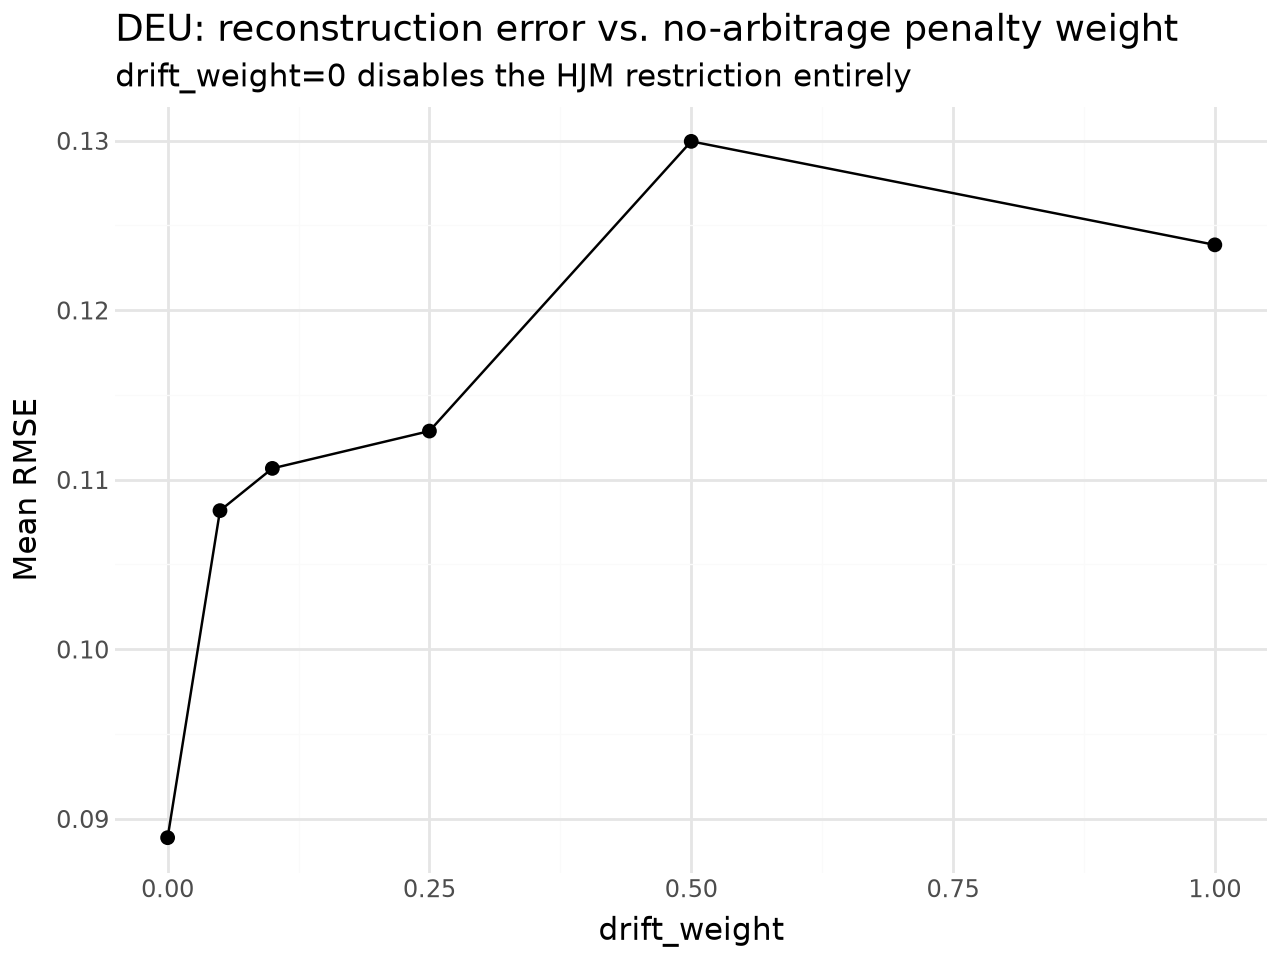

In [7]:
one = long.filter(pl.col(panel.issuer_column) == "DEU")
wide = pivot_to_wide(
    one,
    date_column="date",
    name_column=panel.term_column,
    value_column=panel.rate_column,
)
canonical = _canonical_maturities(list(panel.term_columns))
wide = wide.rename(canonical)
terms = [canonical[t] for t in panel.term_columns]
maturities = _canonical_maturity_values(terms)
_, yields = _dense_rows(wide, "date", terms)

rows = []
for weight in (0.0, 0.05, 0.1, 0.25, 0.5, 1.0):
    fit = fit_panel(
        maturities,
        yields,
        ModelSpec(
            ResidualModel.NEURAL_HJM,
            seed=0,
            neural=NeuralSpec(epochs=400, drift_weight=weight),
        ),
    )
    rows.append(
        {
            "drift_weight": weight,
            "rmse": float(np.mean(fit.rmse)),
            "max_abs_adjustment": float(np.max(np.abs(fit.adjustment))),
        }
    )

sweep = pl.DataFrame(rows)
display(sweep)
(
    ggplot(sweep.to_pandas(), aes("drift_weight", "rmse"))
    + geom_line()
    + geom_point(size=2)
    + labs(
        title="DEU: reconstruction error vs. no-arbitrage penalty weight",
        subtitle="drift_weight=0 disables the HJM restriction entirely",
        x="drift_weight",
        y="Mean RMSE",
    )
    + theme_minimal()
)

The trade-off the penalty exists to manage: pushing `drift_weight` up trades
some reconstruction accuracy for closer adherence to the no-arbitrage
restriction. Where that trade-off should sit is exactly the kind of choice the
missing published hyperparameters leave to the implementer — the default of
`0.1` is this codebase's choice, not one recovered from the paper.

## Chapter G: Summary

* **Chapter E is the point of this notebook.** It is a live counter-example to
  `ycs_af_models.ipynb`'s invariance result: a curve model whose correction
  varies over time *can* move the residual network, and empirically does, on
  the same panel where AFNS and DTAFNS provably cannot.
* **Its residuals remain a different statistical object.** Every RMSE
  comparison above should be read with the filtered/cross-sectional caveat in
  mind — this model has seen the data it is evaluated on.
* **No EKF, particle filter, or CLSTM.** This is a documented subset of one
  2025 preprint with no published reference implementation to validate
  against, not a full reproduction.
* Registered in `ycn.analysis.af_models.FITTERS`; see
  `.mex/patterns/add-residual-model.md` for what a fitter of this shape
  (state-dependent adjustment, not closed-form) needs to implement.

In [8]:
for ref in references_for(ResidualModel.NEURAL_HJM):
    print(f"[{ref.key}] {ref.authors} ({ref.year}). {ref.title}.")
    print(f"    {ref.venue}. {ref.identifier}")
    if ref.notes:
        print(f"    {ref.notes}")
    print()

[gao_hyndman2025_neural_hjm] Gao, X. & Hyndman, C. (2025). Arbitrage-Free Bond and Yield Curve Forecasting with Neural Filters under HJM Constraints.
    arXiv preprint. arXiv:2511.17892
    EXPERIMENTAL, PARTIAL. No code or hyperparameters are published, so ycn implements a documented subset: DNS forward-rate parameterisation, an LSTM latent state, a learned-gain correction and the HJM drift restriction as a soft penalty. Omits the EKF, the particle filter and the CLSTM. Its residuals are filtered in-sample residuals, a different statistical object from the cross-sectional residuals of the other models, and cannot be validated against published numbers.

[hjm1992] Heath, D., Jarrow, R. & Morton, A. (1992). Bond pricing and the term structure of interest rates: a new methodology for contingent claims valuation.
    Econometrica 60(1), 77-105. doi:10.2307/2951677
    The forward-rate drift restriction the neural model penalises departures from.

